## XBOX3 post processing notebook

1. Analysys of single pulses given date/logtype/pulse number
2. Data Extraction from TDMS event and trend data to h5
3. Vacuum spikes - Intensity correlation
4. Summary plot w/o BD location

In [1]:
# Go with pip install -e . 
# Needed to install the package in src in editable mode

%matplotlib widget

import xbox_proc # Structure, DateRange
import matplotlib.pyplot as plt

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from nptdms import TdmsFile
from datetime import datetime

In [7]:
#keys = ["Timestamp", "Line 1 Pressure", "Line 2 Pressure", "DUT 1 Room Temp", "DUT 2 Room Temp", "Pulse Count 2", "Load 2 Pressure", "DUT 2 Pressure", "StructureBSurf_In Temp", "StructureBSurf_Out Temp", "StructureBWater_In Temp", "Load2 Temp", "DUT 2 Flow", "Pulse Count 1", "Load 1 Pressure", "DUT 1 Pressure", "DUT 1 Surf In Temp", "DUT 1 Surf Out Temp", "DUT 1 Water In Temp", "Load 1 RF In Temp", "DUT 1 Flow"]
keys = ["Timestamp", 'Pulse Count 2', 'Klystron B Pressure', 'Hybrid 2 Pressure', 'Pulse Compressor 2 Pressure', 'Line 2 Pressure', "DUT 2 Pressure",'Load 2 Pressure',
        '2PKIA_ampcursor Blue mean ', '2PKIB_ampcursor Blue mean ', '2PLIA_ampcursor Blue mean ', '2PLIB_ampcursor Blue mean ', '2PSI_ampcursor grey mean ', 
        'Gauge Klystron A Pressure', 'Gauge PC 2 Pressure', 'Gauge Line 2 Pressure',  'Gauge Load 2 Pressure', 'Gauge Klystron B Pressure', 'Gauge DUT 2 Pressure',
        'Repetition rate']

s = xbox_proc.Structure(
    name="Xbox3_TD31N2_L2_run2",
    data_dir="//cernbox-drive/winspaces/x/xboxes/Xbox3_TD31N2_L2_run2",
    xbox=3,
    stand=2,
   
    P_ref = 36.1,  # [MW]
    G_ref = 72,  # MV/m
    t_fill=55.75e-9,
    
    BDR_ref=1.7e-6,
    PL_ref=180, # ns

    trend_keys=keys
    )

In [6]:
# Load a TDMS file based on single date file

filepath = s.data_dir / "EventDataB_20260817.tdms"
tdms = TdmsFile.open(filepath)

filepath = s.data_dir / "TrendData_20260817.tdms"
tdms = TdmsFile.open(filepath)

group = tdms.groups()[0]
for el in group.channels():
    print(el.name)
    

sys.cpu0.load
sys.cpu1.load
sys.cpu2.load
sys.cpu3.load
Klystron A Pressure
Hybrid 1 Pressure
Pulse Compressor 1 Pressure
Line 1 Pressure
Load 1 Pressure
DUT 1 Pressure
Klystron B Pressure
Hybrid 2 Pressure
Pulse Compressor 2 Pressure
Line 2 Pressure
Load 2 Pressure
DUT2 Pressure
Klystron Internal A Pressure
Klystron Internal B Pressure
Klystron A Temp
Hybrid 1 Temp
PC1_Left Temp
PC1_Right Temp
PC1_Hybrid Temp
Load 1 Center Temp
Load 1 Side Temp
Load 1 In Temp
Load 1 RF In Temp
Load 1 Out Temp
Klystron B Temp
Hybrid 2 Temp
PC2_Left Temp
PC2_Right Temp
PC2_Hybrid Temp
Load 2 Center Temp
Load 2 Side Temp
Load 2 In Temp
Load 2 RF In Temp
Load 2 Out Temp
Load 1 Flow
Load 2 Flow
1KLYINA_amp max
1KLYINB_amp max
1PKIA_amp max
1PKIB_amp max
1PLIA_amp max
1PLIB_amp max
1PKRA max
1PKRB max
1PSI_amp max
1PEI_amp max
1PSR_amp max
1KLYINA_ampcursor Blue mean 
1KLYINB_ampcursor Blue mean 
1PKIA_ampcursor Blue mean 
1PKIB_ampcursor Blue mean 
1PLIA_ampcursor Blue mean 
1PLIB_ampcursor Blue mean 
1PKR

[<TdmsGroup with path /'Log_2026.08.17-00:00:39.102'>, <TdmsGroup with path /'Log_2026.08.17-00:01:19.202'>, <TdmsGroup with path /'Log_2026.08.17-00:01:59.300'>, <TdmsGroup with path /'Log_2026.08.17-00:02:39.300'>, <TdmsGroup with path /'Log_2026.08.17-00:03:19.300'>, <TdmsGroup with path /'Log_2026.08.17-00:03:59.200'>, <TdmsGroup with path /'Log_2026.08.17-00:04:39.200'>, <TdmsGroup with path /'Log_2026.08.17-00:05:19.200'>, <TdmsGroup with path /'Log_2026.08.17-00:05:59.200'>, <TdmsGroup with path /'Log_2026.08.17-00:06:39.300'>, <TdmsGroup with path /'Log_2026.08.17-00:07:19.301'>, <TdmsGroup with path /'Log_2026.08.17-00:07:59.302'>, <TdmsGroup with path /'Log_2026.08.17-00:08:39.300'>, <TdmsGroup with path /'Log_2026.08.17-00:09:19.200'>, <TdmsGroup with path /'Log_2026.08.17-00:09:59.200'>, <TdmsGroup with path /'Log_2026.08.17-00:10:39.200'>, <TdmsGroup with path /'Log_2026.08.17-00:11:19.202'>, <TdmsGroup with path /'Log_2026.08.17-00:11:59.302'>, <TdmsGroup with path /'Log_

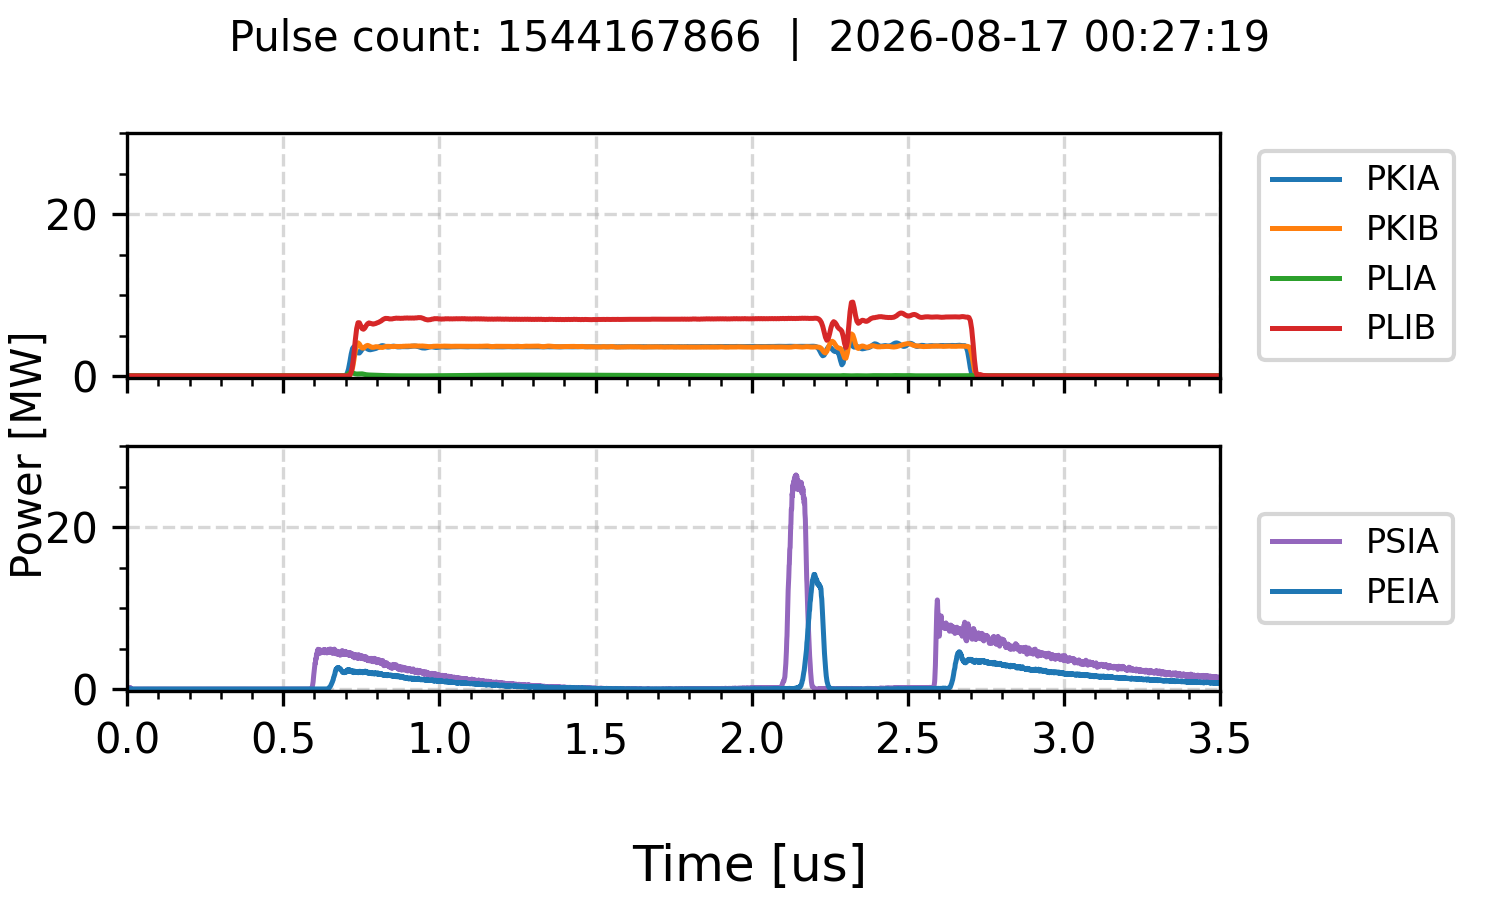

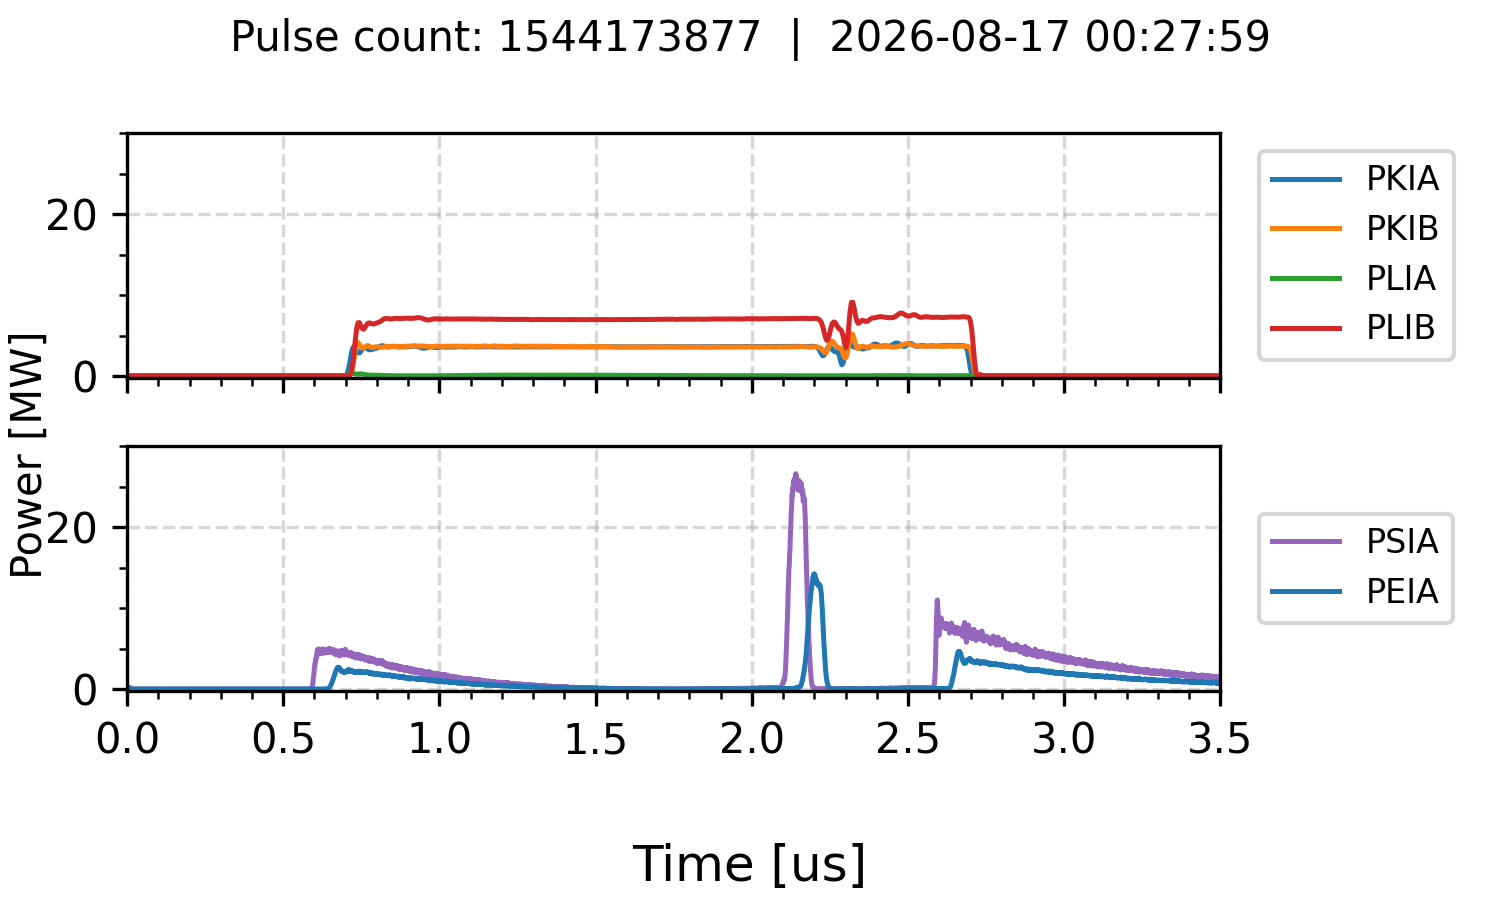

In [8]:
start = pd.Timestamp("2026-08-17 11:00:00")
end   = pd.Timestamp("2026-08-17 12:59:59")

matches = [g for g in tdms.groups() if g.properties.get("Log Type") == 3]
# matches = [g for g in tdms.groups() if g.properties.get("Pulse Count") == 1103244029]
# matches = [g for g in tdms.groups() if (g.properties.get("Log Type") == 2) and (start <= g.properties.get("Timestamp") <= end)]

print(matches)


for i in matches[40:42]:  # 0-based
    
    group = i
    data = {
            "pulse_count": np.array(group.properties["Pulse Count"]),
            "log_type": np.array(group.properties["Log Type"]),
            "timestamp": np.array(group.properties["Timestamp"]),
        }
    #print(data)

    # Need to build x and y axes for each channel

    data_list = ["PKIA_amp","PKIB_amp","PKRA","PKRB", "PLIA_amp", "PLIB_amp", 
                "PLRA", "PLRB", "PSI_amp", "PSR_amp", "PERA", "PERB", "PEI_amp", 
                "DC_UP", "DC_DOWN"]
            
    for el in data_list:
        x=np.arange(0,group[el].properties['wf_samples'])*group[el].properties['wf_increment']
        y=xbox_proc.processing.scaling.get_scaled_channel_data(group[el])
            #PKIA and PKIB
        data.update({f"{el}_x": x, f"{el}_y": y})

    plt.rcParams.update({
        'font.size': 10,
        'axes.titlesize': 10,
        'legend.fontsize': 8,
        'lines.linewidth': 1.2})


    fig, ax = plt.subplots(2, 1, sharex=True, figsize=(5, 3), dpi = 300)

    ax[0].plot(data['PKIA_amp_x']*1e6, data['PKIA_amp_y']/1e6, label='PKIA', color='tab:blue')
    ax[0].plot(data['PKIB_amp_x']*1e6, data['PKIB_amp_y']/1e6, label='PKIB', color='tab:orange')
    ax[0].plot(data['PLIA_amp_x']*1e6, data['PLIA_amp_y']/1e6, label='PLIA', color='tab:green')
    ax[0].plot(data['PLIB_amp_x']*1e6, data['PLIB_amp_y']/1e6, label='PLIB', color='tab:red')

    ax[1].plot(data['PSI_amp_x']*1e6, data['PSI_amp_y']/1e6, label='PSIA', color='tab:purple')
    ax[1].plot(data['PEI_amp_x']*1e6, data['PEI_amp_y']/1e6, label='PEIA', color='tab:blue')

    #ax[2].plot(data['PERA_x'], data['PERA_y']/1e6, label='PERA', color='tab:orange')
    #ax[2].plot(data['PKRA_x'], data['PKRA_y']/1e6, label='PKRA', color='tab:red')
    #ax[2].plot(data['PSR_amp_x'], data['PSR_amp_y']/1e6, label='PSR', color='tab:green')
    #ax[2].plot(data['PKRB_x'], data['PKRB_y']/1e6, label='PKRB', color='tab:purple')

    #ax[2].plot(data['DC_DOWN_x']*1e6, data['DC_DOWN_y'], label='DC_DOWN', color='tab:orange')
   # ax[2].plot(data['DC_UP_x']*1e6, data['DC_UP_y'], label='DC_UP', color='tab:blue')


    #fig.supylabel("Power [MW]")
    # group label (top two plots)
    pos0 = ax[0].get_position()
    pos1 = ax[1].get_position()
    y_center = (pos0.y0 + pos1.y1) / 2

    fig.text(0.02, y_center, "Power [MW]",
         rotation='vertical', va='center', ha='center')

    # separate label for third plot
    #ax[2].set_ylabel("DC [Cnts]")
    fig.supxlabel("Time [us]")

    for axs in ax:
        axs.minorticks_on()
        axs.grid(True, which='major', linestyle='--', alpha=0.5)
        axs.legend(loc='center left', bbox_to_anchor=(1.02, 0.5))
        axs.set_xlim(0, 3.5)
        axs.set_ylim(-0.2, 30)

    #ax[2].set_yscale('log')
    #ax[2].set_ylim(0, 0.4)
    # For DC
    #ax[2].set_ylim(-10000, 250)

    ts = np.atleast_1d(data['timestamp'])[0]
    ts = ts.astype('datetime64[s]').item()

    fig.suptitle(
        f"Pulse count: {data['pulse_count']}  |  "
        #f"Log type: {data['log_type']}  |  "
        f"{ts.strftime('%Y-%m-%d %H:%M:%S')}",
        fontsize=10
    )
    
    fig.tight_layout()
    #plt.savefig("../../20260108_PulseShapes.png", dpi=300)

[<TdmsGroup with path /'Breakdown_2026.08.03-20:13:16.292'>, <TdmsGroup with path /'Breakdown_2026.08.03-21:08:02.393'>, <TdmsGroup with path /'Breakdown_2026.08.03-21:09:18.193'>, <TdmsGroup with path /'Breakdown_2026.08.03-21:36:49.494'>]


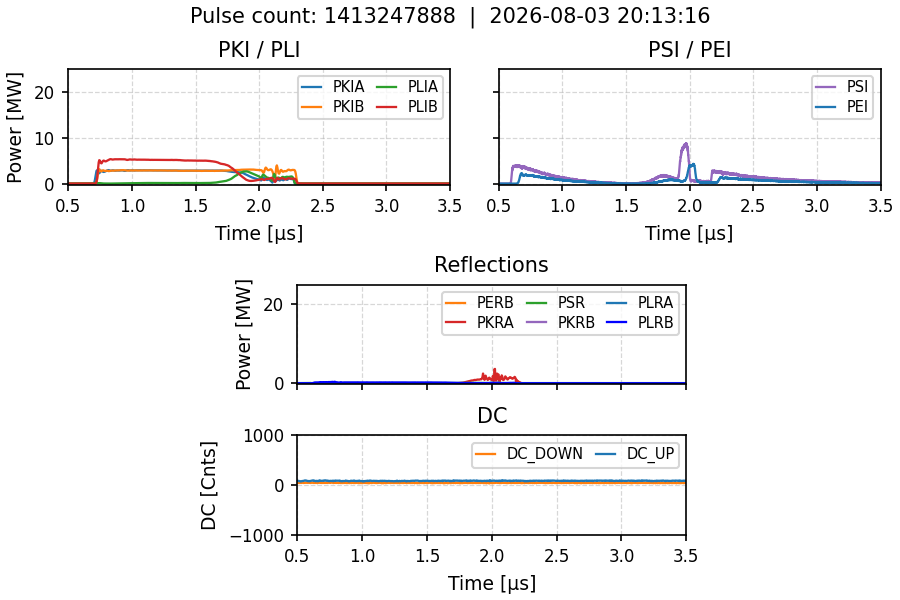

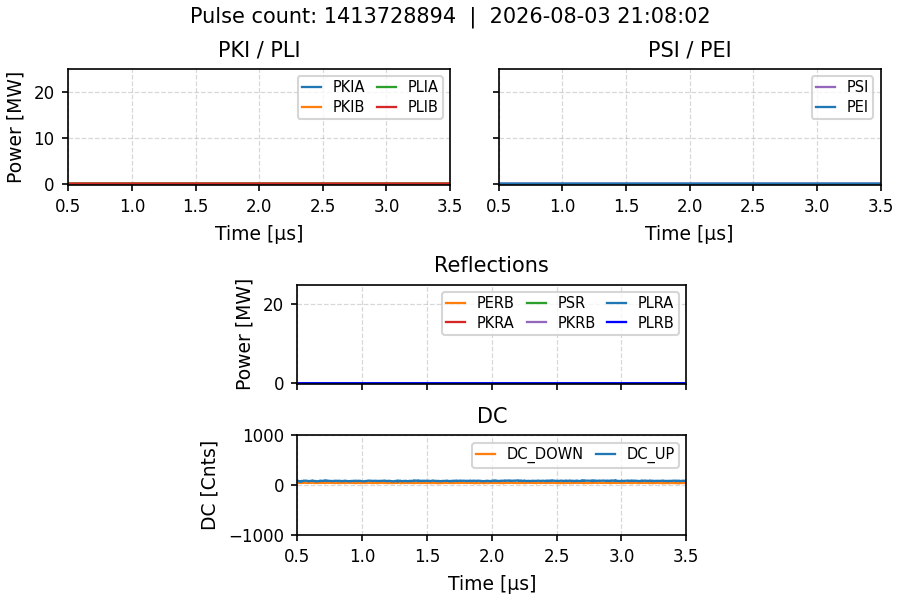

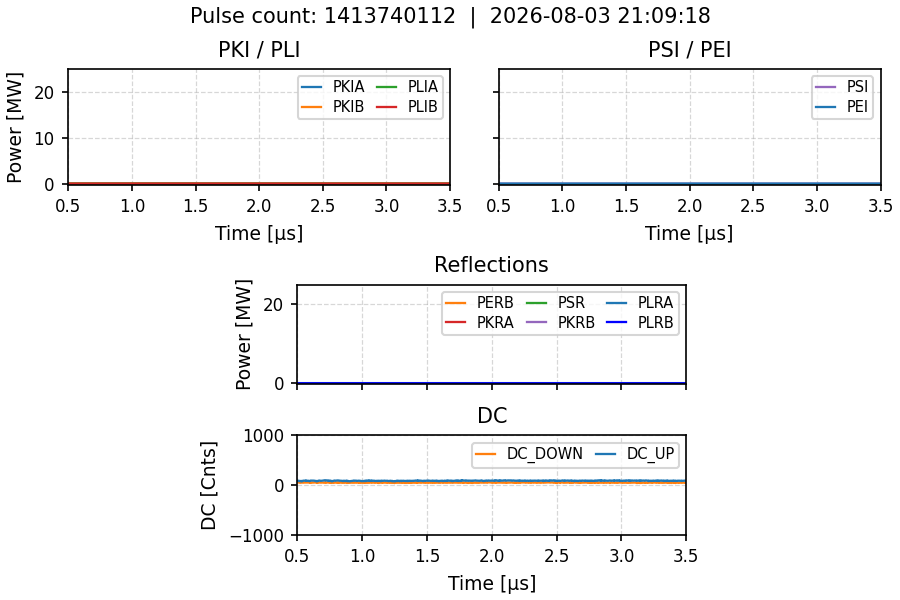

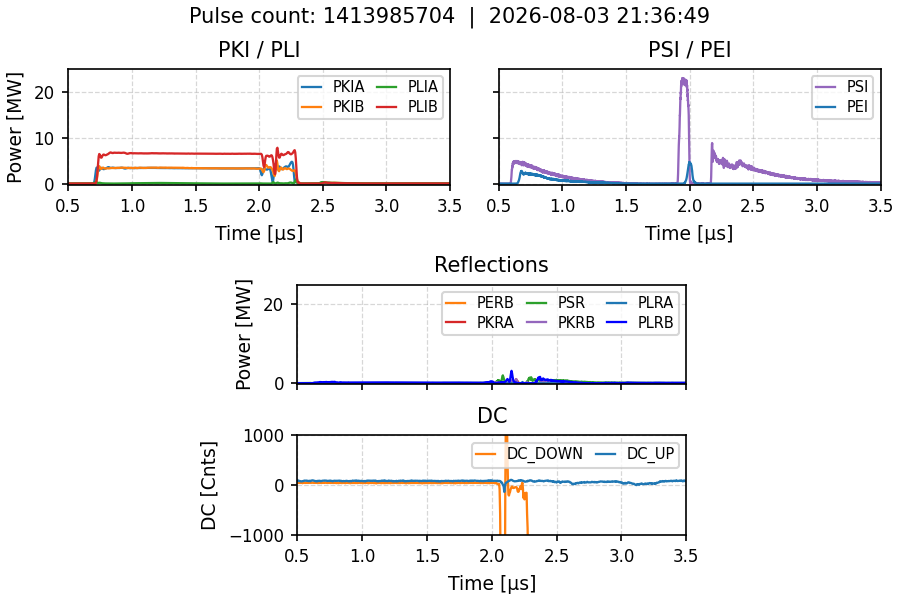

In [22]:
start = pd.Timestamp("2026-08-03 20:00:00")
end   = pd.Timestamp("2026-08-03 23:59:59")

matches = [
    group
    for group in tdms.groups()
    if (
        group.properties.get("Log Type") == 2
        and start <= pd.Timestamp(group.properties.get("Timestamp")) <= end
    )
]

print(matches)

plt.rcParams.update({
    "font.size": 9,
    "axes.titlesize": 10,
    "axes.labelsize": 9,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "legend.fontsize": 7,
    "lines.linewidth": 1.1,
})

data_list = [
    "PKIA_amp",
    "PKIB_amp",
    "PKRA",
    "PKRB",
    "PLIA_amp",
    "PLIB_amp",
    "PLRA",
    "PLRB",
    "PSI_amp",
    "PSR_amp",
    "PERA",
    "PERB",
    "PEI_amp",
    "DC_UP",
    "DC_DOWN",
]

for group in matches:

    data = {
        "pulse_count": group.properties["Pulse Count"],
        "log_type": group.properties["Log Type"],
        "timestamp": group.properties["Timestamp"],
    }

    # Build x and y arrays for every channel
    for channel_name in data_list:
        channel = group[channel_name]

        x = (
            np.arange(channel.properties["wf_samples"])
            * channel.properties["wf_increment"]
        )

        y = xbox_proc.processing.scaling.get_scaled_channel_data(channel)

        data[f"{channel_name}_x"] = x
        data[f"{channel_name}_y"] = y

    # =====================================================
    # Figure layout
    #
    # ┌────────────────┬────────────────┐
    # │ PKI / PLI      │ PSI / PEI      │
    # └────────────────┴────────────────┘
    #
    #        ┌──────────────────┐
    #        │ Reflections      │
    #        └──────────────────┘
    #
    #        ┌──────────────────┐
    #        │ DC               │
    #        └──────────────────┘
    # =====================================================

    fig = plt.figure(
        figsize=(6, 4),
        dpi=150,
        constrained_layout=True,
    )

    # Outer grid:
    # - first row spans full width
    # - last two rows use the middle columns
    outer_gs = fig.add_gridspec(
        nrows=3,
        ncols=4,
        height_ratios=[1.3, 0.6, 0.6],
        width_ratios=[1, 1, 1, 1],
    )

    # Separate grid for the first row.
    # Reduce wspace to bring the two plots closer together.
    top_gs = outer_gs[0, :].subgridspec(
        nrows=1,
        ncols=2,
        width_ratios=[1, 1],
        wspace=0.05,
    )

    ax_power_left = fig.add_subplot(top_gs[0, 0])

    ax_power_right = fig.add_subplot(
        top_gs[0, 1],
        sharex=ax_power_left,
        sharey=ax_power_left,
    )

    # Narrower, centered lower rows
    ax_reflections = fig.add_subplot(
        outer_gs[1, 1:3],
        sharex=ax_power_left,
    )

    ax_dc = fig.add_subplot(
        outer_gs[2, 1:3],
        sharex=ax_power_left,
    )

    # -----------------------------------------------------
    # Top-left: PKI and PLI
    # -----------------------------------------------------
    ax_power_left.plot(
        data["PKIA_amp_x"] * 1e6,
        data["PKIA_amp_y"] / 1e6,
        label="PKIA",
        color="tab:blue",
    )

    ax_power_left.plot(
        data["PKIB_amp_x"] * 1e6,
        data["PKIB_amp_y"] / 1e6,
        label="PKIB",
        color="tab:orange",
    )

    ax_power_left.plot(
        data["PLIA_amp_x"] * 1e6,
        data["PLIA_amp_y"] / 1e6,
        label="PLIA",
        color="tab:green",
    )

    ax_power_left.plot(
        data["PLIB_amp_x"] * 1e6,
        data["PLIB_amp_y"] / 1e6,
        label="PLIB",
        color="tab:red",
    )

    ax_power_left.set_title("PKI / PLI")
    ax_power_left.set_ylabel("Power [MW]")
    ax_power_left.set_xlabel("Time [µs]")

    # -----------------------------------------------------
    # Top-right: PSI and PEI
    # -----------------------------------------------------
    ax_power_right.plot(
        data["PSI_amp_x"] * 1e6,
        data["PSI_amp_y"] / 1e6,
        label="PSI",
        color="tab:purple",
    )

    ax_power_right.plot(
        data["PEI_amp_x"] * 1e6,
        data["PEI_amp_y"] / 1e6,
        label="PEI",
        color="tab:blue",
    )

    ax_power_right.set_title("PSI / PEI")
    ax_power_right.set_xlabel("Time [µs]")

    # Shared y-axis: hide duplicated labels on the right plot
    ax_power_right.tick_params(
        axis="y",
        which="both",
        labelleft=False,
    )

    # -----------------------------------------------------
    # Second row: reflections
    # -----------------------------------------------------
    ax_reflections.plot(
        data["PERB_x"] * 1e6,
        data["PERB_y"] / 1e6,
        label="PERB",
        color="tab:orange",
    )

    ax_reflections.plot(
        data["PKRA_x"] * 1e6,
        data["PKRA_y"] / 1e6,
        label="PKRA",
        color="tab:red",
    )

    ax_reflections.plot(
        data["PSR_amp_x"] * 1e6,
        data["PSR_amp_y"] / 1e6,
        label="PSR",
        color="tab:green",
    )

    ax_reflections.plot(
        data["PKRB_x"] * 1e6,
        data["PKRB_y"] / 1e6,
        label="PKRB",
        color="tab:purple",
    )

    ax_reflections.plot(
        data["PLRA_x"] * 1e6,
        data["PLRA_y"] / 1e6,
        label="PLRA",
        color="tab:blue",
    )

    ax_reflections.plot(
        data["PLRB_x"] * 1e6,
        data["PLRB_y"] / 1e6,
        label="PLRB",
        color="b",
    )

    ax_reflections.set_title("Reflections")
    ax_reflections.set_ylabel("Power [MW]")

    # -----------------------------------------------------
    # Third row: DC
    # -----------------------------------------------------
    ax_dc.plot(
        data["DC_DOWN_x"] * 1e6,
        data["DC_DOWN_y"],
        label="DC_DOWN",
        color="tab:orange",
    )

    ax_dc.plot(
        data["DC_UP_x"] * 1e6,
        data["DC_UP_y"],
        label="DC_UP",
        color="tab:blue",
    )

    ax_dc.set_title("DC")
    ax_dc.set_ylabel("DC [Cnts]")
    ax_dc.set_xlabel("Time [µs]")

    # -----------------------------------------------------
    # Common axis formatting
    # -----------------------------------------------------
    all_axes = [
        ax_power_left,
        ax_power_right,
        ax_reflections,
        ax_dc,
    ]

    x_ticks = np.arange(0.5, 3.6, 0.5)

    for axis in all_axes:
        axis.set_xlim(0.5, 3.5)
        axis.set_xticks(x_ticks)

        # Disable minor ticks
        axis.minorticks_off()

        # Grid only on major ticks
        axis.grid(
            True,
            which="major",
            axis="both",
            linestyle="--",
            linewidth=0.6,
            alpha=0.5,
        )

        axis.tick_params(
            axis="both",
            which="major",
            length=3,
            width=0.8,
        )

    # Shared y-limit for the top-row plots
    ax_power_left.set_ylim(-0.2, 25)

    # Reflection y-limit
    ax_reflections.set_ylim(-0.2, 25)

    # Adjust according to the DC data
    ax_dc.set_ylim(-1000, 1000)

    # -----------------------------------------------------
    # Explicit x-axis tick labels
    # -----------------------------------------------------
    ax_power_left.tick_params(
        axis="x",
        which="major",
        bottom=True,
        labelbottom=True,
    )

    ax_power_right.tick_params(
        axis="x",
        which="major",
        bottom=True,
        labelbottom=True,
    )

    # Hide x tick labels on reflections
    ax_reflections.tick_params(
        axis="x",
        which="major",
        bottom=True,
        labelbottom=False,
    )

    ax_dc.tick_params(
        axis="x",
        which="major",
        bottom=True,
        labelbottom=True,
    )

    # -----------------------------------------------------
    # Legends
    # -----------------------------------------------------
    ax_power_left.legend(
        loc="upper right",
        ncol=2,
        framealpha=0.8,
        borderpad=0.3,
        labelspacing=0.3,
        handlelength=1.3,
        columnspacing=0.8,
    )

    ax_power_right.legend(
        loc="upper right",
        framealpha=0.8,
        borderpad=0.3,
        labelspacing=0.3,
        handlelength=1.3,
    )

    ax_reflections.legend(
        loc="upper right",
        ncol=3,
        framealpha=0.8,
        borderpad=0.3,
        labelspacing=0.3,
        handlelength=1.3,
        columnspacing=0.8,
    )

    ax_dc.legend(
        loc="upper right",
        ncol=2,
        framealpha=0.8,
        borderpad=0.3,
        labelspacing=0.3,
        handlelength=1.3,
        columnspacing=0.8,
    )

    # -----------------------------------------------------
    # Figure title
    # -----------------------------------------------------
    timestamp = pd.Timestamp(data["timestamp"])
    pulse_count = np.asarray(data["pulse_count"]).reshape(-1)[0]

    fig.suptitle(
        f"Pulse count: {pulse_count}  |  "
        f"{timestamp.strftime('%Y-%m-%d %H:%M:%S')}",
        fontsize=10,
    )

    # Optional save command
    # fig.savefig(
    #     f"pulse_{pulse_count}.png",
    #     dpi=300,
    #     bbox_inches="tight",
    # )

    plt.show()

### 1. Data Extraction from TDMS file to h5
1. Defining structure object and keys for trend data
2. Defining data range object
3. Extract Event Data to h5
4. Extract Trend Data to h5
5. Import Event Data from h5 as dataframe with post-processing
6. Import Trend Data from h5

In [8]:
#keys = ["Timestamp", "Line 1 Pressure", "Line 2 Pressure", "DUT 1 Room Temp", "DUT 2 Room Temp", "Pulse Count 2", "Load 2 Pressure", "DUT 2 Pressure", "StructureBSurf_In Temp", "StructureBSurf_Out Temp", "StructureBWater_In Temp", "Load2 Temp", "DUT 2 Flow", "Pulse Count 1", "Load 1 Pressure", "DUT 1 Pressure", "DUT 1 Surf In Temp", "DUT 1 Surf Out Temp", "DUT 1 Water In Temp", "Load 1 RF In Temp", "DUT 1 Flow"]
keys = ["Timestamp", 'Pulse Count 2', 'Klystron B Pressure', 'Hybrid 2 Pressure', 'Pulse Compressor 2 Pressure', 'Line 2 Pressure', "DUT 2 Pressure",'Load 2 Pressure',
        '2PKIA_ampcursor Blue mean ', '2PKIB_ampcursor Blue mean ', '2PLIA_ampcursor Blue mean ', '2PLIB_ampcursor Blue mean ', '2PSI_ampcursor grey mean ', 
        'Gauge Klystron A Pressure', 'Gauge PC 2 Pressure', 'Gauge Line 2 Pressure',  'Gauge Load 2 Pressure', 'Gauge Klystron B Pressure', 'Gauge DUT 2 Pressure',
        'Repetition rate']

s = xbox_proc.Structure(
    name="Xbox3_TD31N2_L2_run2",
    data_dir="//cernbox-drive/winspaces/x/xboxes/Xbox3_TD31N2_L2_run2",
    xbox=3,
    stand=2,
   
    P_ref = 36.1,  # [MW]
    G_ref = 72,  # MV/m
    t_fill=55.75e-9,
    
    BDR_ref=1.7e-6,
    PL_ref=180, # ns

    trend_keys=keys
    )

In [11]:
dr = xbox_proc.DateRange(20260609, 20260817)

In [6]:
event_df = s.extract_events(
    dr,
    out_h5="../data/TD31N2_L2_run2_event_data.h5",
    key="event_data",
    mode="a"   # overwrite for this test (append 'a' otherwise)
)

event_df.head()

EventDataB_20260804.tdms:  22%|██▏       | 528/2439 [00:23<01:27, 21.88it/s]

: 

: 

In [12]:
trend_df = s.extract_trends(
    dr,
    out_h5="../data/TD31N2_L2_run2_trend_data.h5",
    key="trend_data",
    mode="w"
)

trend_df.head()

c:\Users\lsito\AppData\Local\miniconda3\envs\xbox\Lib\site-packages\tables\path.py:146: NaturalNameWarning: object name is not a valid Python identifier: 'Pulse Count 2'; it does not match the pattern ``^[a-zA-Z_][a-zA-Z0-9_]*`; you will not be able to use natural naming to access this object; using ``getattr()`` will still work, though
  check_attribute_name(name)
c:\Users\lsito\AppData\Local\miniconda3\envs\xbox\Lib\site-packages\tables\path.py:146: NaturalNameWarning: object name is not a valid Python identifier: 'Klystron B Pressure'; it does not match the pattern ``^[a-zA-Z_][a-zA-Z0-9_]*$``; you will not be able to use natural naming to access this object; using ``getattr()`` will still work, though
  check_attribute_name(name)
c:\Users\lsito\AppData\Local\miniconda3\envs\xbox\Lib\site-packages\tables\path.py:146: NaturalNameWarning: object name is not a valid Python identifier: 'Hybrid 2 Pressure'; it does not match the pattern ``^[a-zA-Z_][a-zA-Z0-9_]*$``; you will not be able 

,Timestamp,Pulse Count 2,Klystron B Pressure,Hybrid 2 Pressure,Pulse Compressor 2 Pressure,Line 2 Pressure,DUT 2 Pressure,Load 2 Pressure,2PKIA_ampcursor Blue mean,2PKIB_ampcursor Blue mean,2PLIA_ampcursor Blue mean,2PLIB_ampcursor Blue mean,2PSI_ampcursor grey mean,Gauge Klystron A Pressure,Gauge PC 2 Pressure,Gauge Line 2 Pressure,Gauge Load 2 Pressure,Gauge Klystron B Pressure,Gauge DUT 2 Pressure,Repetition rate
0,2026-06-09 00:00:00.722051144,996969538.0,5.066717e-09,2.510651e-09,7.097650e-09,3.329412e-09,NaN,3.256115e-10,1.996215e+06,1.990556e+06,32331.517265,3.685417e+06,6.200271e+06,NaN,NaN,NaN,NaN,NaN,NaN,300.002100
1,2026-06-09 00:00:01.728151798,996969685.0,5.085094e-09,2.540250e-09,7.146954e-09,3.344123e-09,NaN,3.265046e-10,1.996268e+06,1.989656e+06,32695.807837,3.675717e+06,6.153604e+06,NaN,NaN,NaN,NaN,NaN,NaN,299.960705
2,2026-06-09 00:00:02.738110542,996969844.0,5.061005e-09,2.527988e-09,7.112905e-09,3.340526e-09,NaN,3.260056e-10,1.996268e+06,1.989656e+06,32695.807837,3.675717e+06,6.153604e+06,NaN,NaN,NaN,NaN,NaN,NaN,300.002100
3,2026-06-09 00:00:03.728909492,996969993.0,5.044445e-09,2.522369e-09,7.093889e-09,3.327430e-09,NaN,3.257093e-10,2.003276e+06,2.002594e+06,32476.924286,3.699082e+06,6.194760e+06,NaN,NaN,NaN,NaN,NaN,NaN,300.002100
4,2026-06-09 00:00:04.779086590,996970162.0,5.050107e-09,2.533673e-09,7.124655e-09,3.335030e-09,NaN,3.259079e-10,1.996695e+06,1.985381e+06,32652.918449,3.675606e+06,6.139228e+06,NaN,NaN,NaN,NaN,NaN,NaN,300.002100


In [13]:
s.load(path="../data/TD31N2_L2_run2_trend_data.h5", key="trend_data")
df_trend = s.df

In [14]:
display(df_trend.head())
display(df_trend.tail())

,Timestamp,Pulse Count 2,Klystron B Pressure,Hybrid 2 Pressure,Pulse Compressor 2 Pressure,Line 2 Pressure,DUT 2 Pressure,Load 2 Pressure,2PKIA_ampcursor Blue mean,2PKIB_ampcursor Blue mean,2PLIA_ampcursor Blue mean,2PLIB_ampcursor Blue mean,2PSI_ampcursor grey mean,Gauge Klystron A Pressure,Gauge PC 2 Pressure,Gauge Line 2 Pressure,Gauge Load 2 Pressure,Gauge Klystron B Pressure,Gauge DUT 2 Pressure,Repetition rate
0,2026-06-09 00:00:00.722051144,996969538.0,5.066717e-09,2.510651e-09,7.097650e-09,3.329412e-09,NaN,3.256115e-10,1.996215e+06,1.990556e+06,32331.517265,3.685417e+06,6.200271e+06,NaN,NaN,NaN,NaN,NaN,NaN,300.002100
1,2026-06-09 00:00:01.728151798,996969685.0,5.085094e-09,2.540250e-09,7.146954e-09,3.344123e-09,NaN,3.265046e-10,1.996268e+06,1.989656e+06,32695.807837,3.675717e+06,6.153604e+06,NaN,NaN,NaN,NaN,NaN,NaN,299.960705
2,2026-06-09 00:00:02.738110542,996969844.0,5.061005e-09,2.527988e-09,7.112905e-09,3.340526e-09,NaN,3.260056e-10,1.996268e+06,1.989656e+06,32695.807837,3.675717e+06,6.153604e+06,NaN,NaN,NaN,NaN,NaN,NaN,300.002100
3,2026-06-09 00:00:03.728909492,996969993.0,5.044445e-09,2.522369e-09,7.093889e-09,3.327430e-09,NaN,3.257093e-10,2.003276e+06,2.002594e+06,32476.924286,3.699082e+06,6.194760e+06,NaN,NaN,NaN,NaN,NaN,NaN,300.002100
4,2026-06-09 00:00:04.779086590,996970162.0,5.050107e-09,2.533673e-09,7.124655e-09,3.335030e-09,NaN,3.259079e-10,1.996695e+06,1.985381e+06,32652.918449,3.675606e+06,6.139228e+06,NaN,NaN,NaN,NaN,NaN,NaN,300.002100


,Timestamp,Pulse Count 2,Klystron B Pressure,Hybrid 2 Pressure,Pulse Compressor 2 Pressure,Line 2 Pressure,DUT 2 Pressure,Load 2 Pressure,2PKIA_ampcursor Blue mean,2PKIB_ampcursor Blue mean,2PLIA_ampcursor Blue mean,2PLIB_ampcursor Blue mean,2PSI_ampcursor grey mean,Gauge Klystron A Pressure,Gauge PC 2 Pressure,Gauge Line 2 Pressure,Gauge Load 2 Pressure,Gauge Klystron B Pressure,Gauge DUT 2 Pressure,Repetition rate
5177433,2026-08-16 23:59:55.009198189,1.543921e+09,1.257274e-08,7.346038e-09,3.937476e-08,6.988934e-09,NaN,1.737873e-09,3.620050e+06,3.613769e+06,86746.394026,7.008579e+06,2.557944e+07,NaN,NaN,NaN,NaN,NaN,NaN,300.0012
5177434,2026-08-16 23:59:56.009239674,1.543921e+09,1.257766e-08,7.353891e-09,3.937476e-08,6.998779e-09,NaN,1.702812e-09,3.619227e+06,3.621425e+06,86351.963128,7.006994e+06,2.566781e+07,NaN,NaN,NaN,NaN,NaN,NaN,300.0012
5177435,2026-08-16 23:59:57.009181976,1.543922e+09,1.256423e-08,7.337043e-09,3.946928e-08,7.001880e-09,NaN,1.735791e-09,3.619227e+06,3.621425e+06,86351.963128,7.006994e+06,2.566781e+07,NaN,NaN,NaN,NaN,NaN,NaN,300.0012
5177436,2026-08-16 23:59:58.009249210,1.543922e+09,1.257012e-08,7.300802e-09,3.934501e-08,7.013753e-09,NaN,1.755034e-09,3.619227e+06,3.621425e+06,86351.963128,7.006994e+06,2.566781e+07,NaN,NaN,NaN,NaN,NaN,NaN,300.0012
5177437,2026-08-16 23:59:59.009228706,1.543922e+09,1.259223e-08,7.326517e-09,3.940669e-08,7.006636e-09,NaN,1.706815e-09,3.619227e+06,3.621425e+06,86351.963128,7.006994e+06,2.566781e+07,NaN,NaN,NaN,NaN,NaN,NaN,300.0012


In [10]:
# Load the event_data df in s object
s.load(path="../data/TD31N2_L2_run2_event_data.h5", key="event_data")
s.post_process()

c:\Users\lsito\AppData\Local\miniconda3\envs\xbox\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: invalid value encountered in sqrt
  result = getattr(ufunc, method)(*inputs, **kwargs)


,pulse_count,log_type,timestamp,PKIA_amp_total_power,PKIA_amp_length,PKIA_amp_peak,PKIA_amp_mean,PKIA_amp_start,PKIB_amp_total_power,PKIB_amp_length,...,BD_time,cum_BD_Load_B,cum_BD_DUT_withDC_B,cum_BD_DUT_withoutDC_B,cum_BD_HyPC_B,BDR_DUT_B,BDR_Load_B,BDR_HyPC_B,gradient_B,scaled_gradient_B
0,953273374,2,2026-06-01 07:14:07.776207,0.033615,0.000005,6.932602e+03,6.733317e+03,0.000000e+00,-0.185160,0.000000,...,8.250000e-08,0,0,0,0,0.0,0.0,0.0,0.423662,inf
1,953273374,3,2026-06-01 07:14:47.975366,0.033613,0.000005,6.956162e+03,6.733306e+03,0.000000e+00,-0.185445,0.000000,...,3.000000e-08,0,0,0,0,0.0,0.0,0.0,0.338279,inf
2,953273374,3,2026-06-01 07:15:48.076252,0.033616,0.000005,6.980989e+03,6.733746e+03,0.000000e+00,-0.185184,0.000000,...,3.000000e-08,0,0,0,0,0.0,0.0,0.0,0.670692,inf
3,953273374,3,2026-06-01 07:16:48.076569,0.033615,0.000005,6.993877e+03,6.733135e+03,0.000000e+00,-0.185336,0.000000,...,3.000000e-08,0,0,0,0,0.0,0.0,0.0,0.617031,inf
4,953273374,3,2026-06-01 07:17:47.975424,0.033613,0.000005,6.956162e+03,6.732852e+03,0.000000e+00,-0.185400,0.000000,...,3.000000e-08,0,0,0,0,0.0,0.0,0.0,0.423662,inf
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45094,1415219227,3,2026-08-03 23:56:49.193989,5.234286,0.000002,4.239916e+06,3.375503e+06,7.131250e-07,5.357019,0.000002,...,3.000000e-08,35,82,0,1422,0.0,0.0,0.0,57.781700,inf
45095,1415225237,3,2026-08-03 23:57:29.293823,5.236663,0.000002,4.292121e+06,3.375674e+06,7.175000e-07,5.344001,0.000002,...,3.000000e-08,35,82,0,1422,0.0,0.0,0.0,57.465793,inf
45096,1415231246,3,2026-08-03 23:58:09.293817,5.237122,0.000002,4.243920e+06,3.375792e+06,7.175000e-07,5.356776,0.000002,...,3.000000e-08,35,82,0,1422,0.0,0.0,0.0,57.992305,inf
45097,1415237223,3,2026-08-03 23:58:49.193844,5.246446,0.000002,4.238581e+06,3.382055e+06,7.175000e-07,5.350896,0.000002,...,3.000000e-08,35,82,0,1422,0.0,0.0,0.0,57.413142,inf


In [11]:
df_event = s.df
display(df_event.head())
display(df_event.tail())

,pulse_count,log_type,timestamp,PKIA_amp_total_power,PKIA_amp_length,PKIA_amp_peak,PKIA_amp_mean,PKIA_amp_start,PKIB_amp_total_power,PKIB_amp_length,...,BD_time,cum_BD_Load_B,cum_BD_DUT_withDC_B,cum_BD_DUT_withoutDC_B,cum_BD_HyPC_B,BDR_DUT_B,BDR_Load_B,BDR_HyPC_B,gradient_B,scaled_gradient_B
0,953273374,2,2026-06-01 07:14:07.776207,0.033615,0.000005,6932.6022,6733.317218,0.0,-0.185160,0.0,...,8.250000e-08,0,0,0,0,0.0,0.0,0.0,0.423662,inf
1,953273374,3,2026-06-01 07:14:47.975366,0.033613,0.000005,6956.1624,6733.306042,0.0,-0.185445,0.0,...,3.000000e-08,0,0,0,0,0.0,0.0,0.0,0.338279,inf
2,953273374,3,2026-06-01 07:15:48.076252,0.033616,0.000005,6980.9890,6733.745832,0.0,-0.185184,0.0,...,3.000000e-08,0,0,0,0,0.0,0.0,0.0,0.670692,inf
3,953273374,3,2026-06-01 07:16:48.076569,0.033615,0.000005,6993.8772,6733.134744,0.0,-0.185336,0.0,...,3.000000e-08,0,0,0,0,0.0,0.0,0.0,0.617031,inf
4,953273374,3,2026-06-01 07:17:47.975424,0.033613,0.000005,6956.1624,6732.851782,0.0,-0.185400,0.0,...,3.000000e-08,0,0,0,0,0.0,0.0,0.0,0.423662,inf


,pulse_count,log_type,timestamp,PKIA_amp_total_power,PKIA_amp_length,PKIA_amp_peak,PKIA_amp_mean,PKIA_amp_start,PKIB_amp_total_power,PKIB_amp_length,...,BD_time,cum_BD_Load_B,cum_BD_DUT_withDC_B,cum_BD_DUT_withoutDC_B,cum_BD_HyPC_B,BDR_DUT_B,BDR_Load_B,BDR_HyPC_B,gradient_B,scaled_gradient_B
45094,1415219227,3,2026-08-03 23:56:49.193989,5.234286,0.000002,4.239916e+06,3.375503e+06,7.131250e-07,5.357019,0.000002,...,3.000000e-08,35,82,0,1422,0.0,0.0,0.0,57.781700,inf
45095,1415225237,3,2026-08-03 23:57:29.293823,5.236663,0.000002,4.292121e+06,3.375674e+06,7.175000e-07,5.344001,0.000002,...,3.000000e-08,35,82,0,1422,0.0,0.0,0.0,57.465793,inf
45096,1415231246,3,2026-08-03 23:58:09.293817,5.237122,0.000002,4.243920e+06,3.375792e+06,7.175000e-07,5.356776,0.000002,...,3.000000e-08,35,82,0,1422,0.0,0.0,0.0,57.992305,inf
45097,1415237223,3,2026-08-03 23:58:49.193844,5.246446,0.000002,4.238581e+06,3.382055e+06,7.175000e-07,5.350896,0.000002,...,3.000000e-08,35,82,0,1422,0.0,0.0,0.0,57.413142,inf
45098,1415243234,3,2026-08-03 23:59:29.193999,5.237835,0.000002,4.243920e+06,3.375910e+06,7.175000e-07,5.361444,0.000002,...,3.000000e-08,35,82,0,1422,0.0,0.0,0.0,57.992305,inf


### 3. Vacuum Spikes - Intensity correlation plot

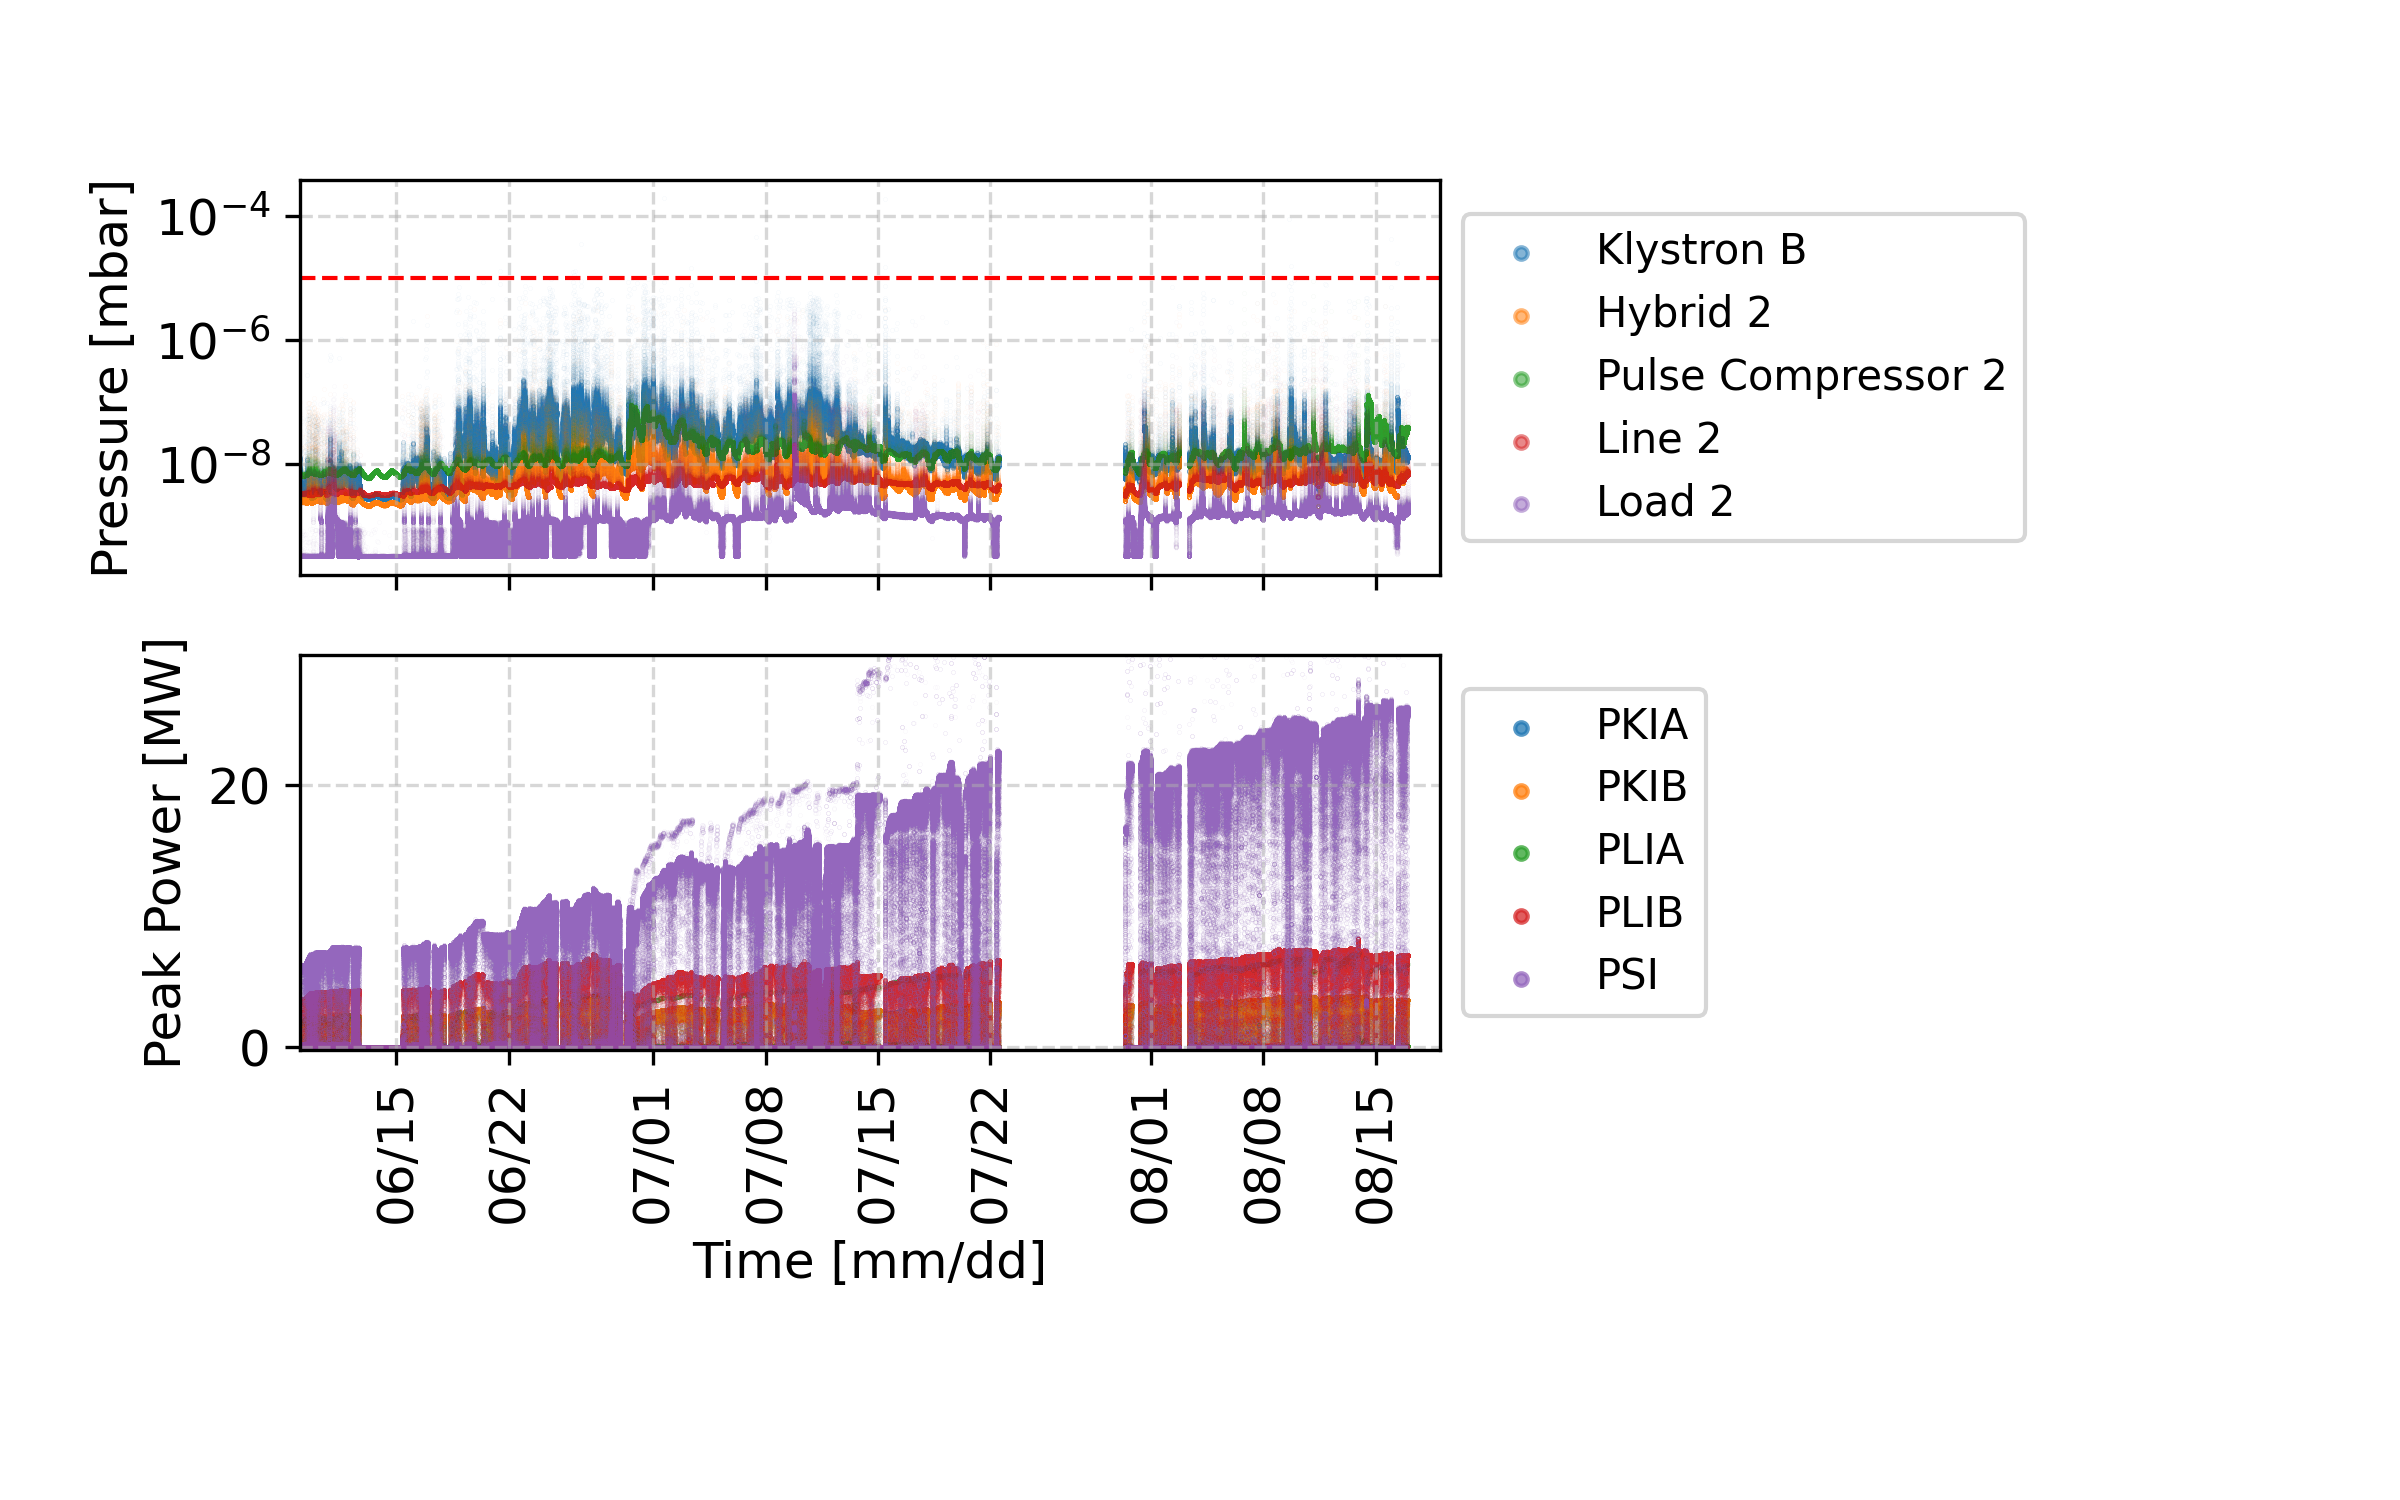

In [15]:
import matplotlib.dates as mdates

plt.rcParams.update({
    'font.size': 12,
    'axes.titlesize': 12,
    'legend.fontsize': 10,
    'lines.linewidth': 1})

fig, ax = plt.subplots(2, 1, figsize=(8, 5), sharex=True, dpi=300)

plot_keys_trend = ['Klystron B Pressure', 'Hybrid 2 Pressure', 'Pulse Compressor 2 Pressure', 'Line 2 Pressure', 'Load 2 Pressure']
labels_trend = ['Klystron B', 'Hybrid 2', 'Pulse Compressor 2', 'Line 2', 'Load 2', 'DUT 2']
plot_keys_power = ['2PKIA_ampcursor Blue mean ', '2PKIB_ampcursor Blue mean ', '2PLIA_ampcursor Blue mean ', '2PLIB_ampcursor Blue mean ', '2PSI_ampcursor grey mean ']
labels_power = ['PKIA', 'PKIB', 'PLIA', 'PLIB',  'PSI']

for idx, el in enumerate(plot_keys_trend):
    ax[0].scatter(df_trend['Timestamp'], df_trend[el], label=labels_trend[idx], s=0.0001, alpha = 0.55)
ax[0].set_yscale('log')

for idx, el in enumerate(plot_keys_power):
    ax[1].scatter(df_trend['Timestamp'], df_trend[el]/1e6, label=labels_power[idx], s=0.0001, alpha = 0.75)
    ax[1].set_ylim(-0.2, 30)

start = pd.Timestamp("2026-06-09 00:00:00")
end   = pd.Timestamp("2026-08-18 23:59:59")

for axs in ax:
    axs.set_xlim(start, end)

for axs in ax:
    axs.grid(True, which='both', linestyle='--', alpha=0.5)
    axs.legend(
        loc='center left',
        bbox_to_anchor=(1.02, 0.5),
        borderaxespad=0.0,
        markerscale=300
    )

ax[0].axhline(y=1e-5, color='r', linestyle='--', label='1e-5 mbar')
ax[-1].xaxis.set_major_formatter(mdates.DateFormatter('%m/%d'))
plt.setp(ax[-1].get_xticklabels(), rotation=90)
#ax[2].plot(df_trend['Timestamp'], df_trend['Repetition rate'])

ax[0].set_ylabel("Pressure [mbar]")
ax[1].set_ylabel("Peak Power [MW]")
ax[1].set_xlabel("Time [mm/dd]")

# Make room on the right
fig.subplots_adjust(right=0.6, bottom=0.3)
# fig.set_tight_layout

# plt.savefig("../../20261912_1705_RepRate200Hz_Jumping_VacuumActivity.png", bbox_inches='tight', dpi=150)                            

### 4. Summary plot - PSI/BDR/plswidth vs Pulses

In [16]:
# Load the event_data df in s object
s.load(path="../data/TD31N2_L2_run2_event_data.h5", key="event_data")
s.post_process()

df_event = s.df

s.load(path="../data/TD31N2_L2_run2_trend_data.h5", key="trend_data")
df_trend = s.df

start = pd.Timestamp("2026-06-09 00:00:00")
end   = pd.Timestamp("2026-08-17 23:59:59")

c:\Users\lsito\AppData\Local\miniconda3\envs\xbox\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: invalid value encountered in sqrt
  result = getattr(ufunc, method)(*inputs, **kwargs)


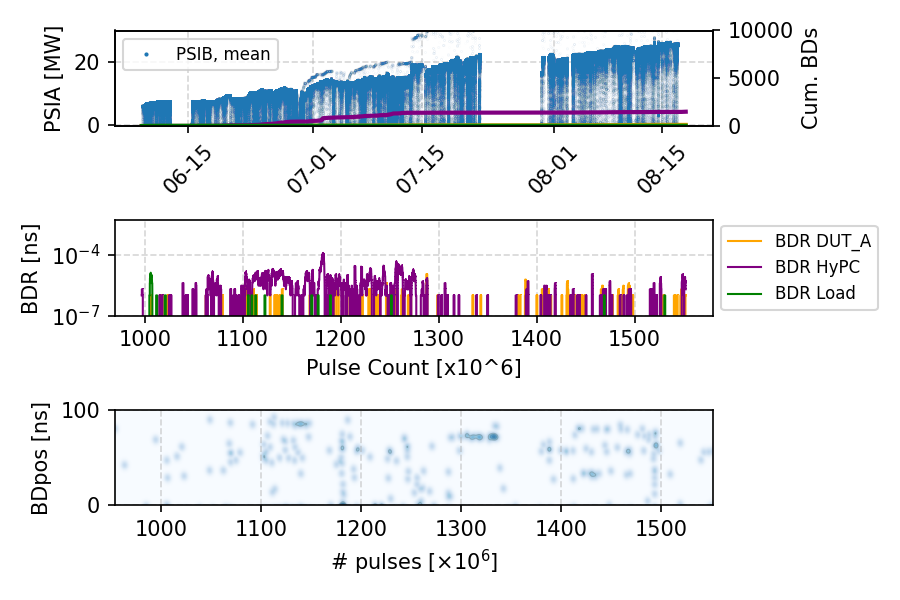

In [17]:
# Plotting
from matplotlib import colors as mcolors
import matplotlib.dates as mdates

plt.rcParams.update({
    'font.size': 10,
    'axes.titlesize': 10,
    'legend.fontsize': 8,
    'lines.linewidth': 1})

fig, ax = plt.subplots(3, 1, figsize=(6,4), dpi=150)

normaldata = df_event.query('timestamp >= @start and timestamp < @end')
normaldata_trend = df_trend.query('Timestamp >= @start and Timestamp < @end')
#normaldata = s.df.query("PKIA_amp_length>10e-9")

ax[0].plot(normaldata_trend["Timestamp"],normaldata_trend["2PSI_ampcursor grey mean "]/1e6,'o', label = "PSIB, mean", color='tab:blue', markersize=0.005)
# ax[0].plot(normaldata["pulse_count"]/1e6,normaldata["PKIA_amp_mean"],',r')
# ax[0].set_xlabel("Date")
ax[0].xaxis.set_major_formatter(mdates.DateFormatter('%m-%d'))
ax[0].xaxis.set_major_locator(mdates.AutoDateLocator())
ax[0].tick_params(axis='x', rotation=45)
ax[0].set_ylim([-0.2,30])
ax[0].set_ylabel("PSIA [MW]")
ax[0].legend(markerscale=200)

ax2=ax[0].twinx()
ax2.plot(normaldata["timestamp"],normaldata["cum_BD_DUT_withDC_B"]+normaldata["cum_BD_DUT_withoutDC_B"],'orange', lw=2) #because I messed up
ax2.plot(normaldata["timestamp"],normaldata["cum_BD_HyPC_B"],'purple', lw=2) #because I messed up
ax2.plot(normaldata["timestamp"],normaldata["cum_BD_Load_B"],'g', lw=2)

ax2.set_ylabel("Cum. BDs")
ax2.set_ylim([0,10000])

ax[1].plot(normaldata["pulse_count"]/1e6,normaldata["BDR_DUT_B"],color='orange', marker=',')
ax[1].plot(normaldata["pulse_count"]/1e6,normaldata["BDR_HyPC_B"],color='purple', marker=',')
ax[1].plot(normaldata["pulse_count"]/1e6,normaldata["BDR_Load_B"],'g')

ax[1].set_yscale('log')
ax[1].set_ylim([1e-7,5e-3])
ax[1].set_ylabel("BDR [ns]")
ax[1].set_xlabel("Pulse Count [x10^6]")
ax[1].legend(['BDR DUT_A','BDR HyPC','BDR Load',], loc='center left',
    bbox_to_anchor=(1, 0.5))

s.df = df_event.query("log_type==2")

[xi, yi, zi, positions] = s.gaussian_kde_calc(kernel_factor=20., 
                          xbin=3000, 
                          ybin=500, 
                          y_min=0, 
                          y_max=10e-8*1e9)

ax[2].pcolormesh(xi/1e6,yi,zi,cmap="Blues",norm=mcolors.PowerNorm(0.5),alpha=1,shading='auto')
ax[2].contour(xi/1e6,yi,zi,cmap='gray',alpha=0.2,linewidths=0.5)
ax[2].set_ylabel("BDpos [ns]")
ax[2].set_xlabel(r"# pulses [$\times 10^6$]")

for axs in ax:
    axs.grid(True, which='both', linestyle='--', alpha=0.5)

plt.tight_layout()

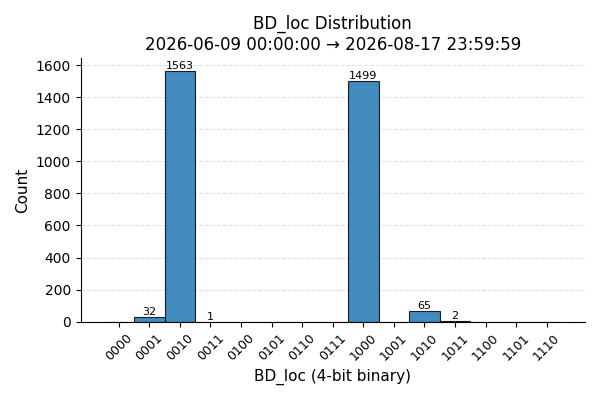

In [18]:
data = df_event
data = data.query('BD_loc > 0')
data = data.query('timestamp >= @start and timestamp < @end')
data = data["BD_loc"]

fig, ax = plt.subplots(figsize=(6, 4))

# Integer-centered bins
bins = np.arange(-0.5, 15.5, 1)

counts, edges, patches = ax.hist(
    data,
    bins=bins,
    edgecolor="black",
    linewidth=0.8,
    alpha=0.85
)

# X ticks as 4-bit binary
ax.set_xticks(range(15))
ax.set_xticklabels([format(i, "04b") for i in range(15)], fontsize=9)

# Labels and title
ax.set_xlabel("BD_loc (4-bit binary)", fontsize=11)
ax.set_ylabel("Count", fontsize=11)
ax.set_title(f"BD_loc Distribution\n{start} → {end}", fontsize=12)

# Subtle grid
ax.grid(axis="y", linestyle="--", alpha=0.4)
ax.set_axisbelow(True)

# Remove top/right spines (cleaner look)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.setp(ax.get_xticklabels(), rotation=45)

# Add count labels above bars (optional but nice)
for i, count in enumerate(counts):
    if count > 0:
        ax.text(i, count, int(count),
                ha="center", va="bottom", fontsize=8)

plt.tight_layout()
plt.show()